# Within-Sample Pseudospace Comparison

**Purpose**: Establish a baseline by comparing replicates within the same condition.
If harmony integration and pseudospace reconstruction are working correctly,
same-condition samples should show very similar gene expression trends along pseudospace.

**Comparisons**:
- `Ctrl_1A2` vs `Ctrl_1A4` (mouse healthy replicates)
- `IR_2A2` vs `IR_2A4` (mouse AKI replicates)
- `HUK1_COR1` vs `HUK1_MED1` (human replicates)

**Metric**: `area_between` — area between expression curves binned along pseudospace (same metric used in `harmony_integration.ipynb`).

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr, spearmanr
from scipy.integrate import trapezoid

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Existing Pseudospace Data

Load the pre-computed pseudospace h5ad files from the harmony integration pipeline. No recalculation.

In [2]:
TUBULE_TYPES = ['PT', 'TAL', 'DCT', 'CNT_CD']
BASE_DIR = 'harmony_integration/tubule_types'

tubule_data = {}

for tt in TUBULE_TYPES:
    path = os.path.join(BASE_DIR, tt, f'{tt}_ortholog_space.h5ad')
    print(f"Loading {tt} from {path}...")
    adata = sc.read_h5ad(path)
    
    # Find pseudospace column
    ps_col = None
    for col in ['pseudospace', 'pseudospace_final', 'position_percentile']:
        if col in adata.obs.columns:
            ps_col = col
            break
    
    if ps_col is None:
        print(f"  ⚠️ No pseudospace column found for {tt}")
        continue
    
    print(f"  Cells: {adata.n_obs}, Genes: {adata.n_vars}")
    print(f"  Pseudospace column: '{ps_col}'")
    print(f"  Samples: {adata.obs['sample'].value_counts().to_dict()}")
    print()
    
    tubule_data[tt] = {'adata': adata, 'ps_col': ps_col}

Loading PT from harmony_integration/tubule_types/PT/PT_ortholog_space.h5ad...
  Cells: 14070, Genes: 15668
  Pseudospace column: 'pseudospace'
  Samples: {'IR_2A4': 3213, 'HUK1_MED1_tubules_filtered_caleb.h5ad': 2883, 'HUK1_COR1_tubules_filtered_caleb.h5ad': 2599, 'IR_2A2': 2014, 'Ctrl_1A4': 1730, 'Ctrl_1A2': 1631}

Loading TAL from harmony_integration/tubule_types/TAL/TAL_ortholog_space.h5ad...
  Cells: 9611, Genes: 15668
  Pseudospace column: 'pseudospace'
  Samples: {'IR_2A2': 2414, 'Ctrl_1A2': 1904, 'IR_2A4': 1557, 'HUK1_MED1_tubules_filtered_caleb.h5ad': 1370, 'Ctrl_1A4': 1326, 'HUK1_COR1_tubules_filtered_caleb.h5ad': 1040}

Loading DCT from harmony_integration/tubule_types/DCT/DCT_ortholog_space.h5ad...
  Cells: 1835, Genes: 15668
  Pseudospace column: 'pseudospace'
  Samples: {'HUK1_MED1_tubules_filtered_caleb.h5ad': 464, 'HUK1_COR1_tubules_filtered_caleb.h5ad': 428, 'IR_2A4': 315, 'IR_2A2': 311, 'Ctrl_1A4': 160, 'Ctrl_1A2': 157}

Loading CNT_CD from harmony_integration/tubule_t

## 2. Define Within-Sample Comparison Pairs

In [3]:
# Within-condition replicate comparisons
WITHIN_COMPARISONS = {
    'Mouse_Ctrl_1A2_vs_1A4': ('Ctrl_1A2', 'Ctrl_1A4'),
    'Mouse_IR_2A2_vs_2A4': ('IR_2A2', 'IR_2A4'),
    'Human_COR1_vs_MED1': ('HUK1_COR1_tubules_filtered_caleb.h5ad', 'HUK1_MED1_tubules_filtered_caleb.h5ad'),
}

COMPARISON_LABELS = {
    'Mouse_Ctrl_1A2_vs_1A4': 'Mouse Healthy (Ctrl 1A2 vs 1A4)',
    'Mouse_IR_2A2_vs_2A4': 'Mouse AKI (IR 2A2 vs 2A4)',
    'Human_COR1_vs_MED1': 'Human (COR1 vs MED1)',
}

COMPARISON_COLORS = {
    'Mouse_Ctrl_1A2_vs_1A4': '#2196F3',
    'Mouse_IR_2A2_vs_2A4': '#F44336',
    'Human_COR1_vs_MED1': '#4CAF50',
}

print("Within-sample comparisons:")
for name, (s1, s2) in WITHIN_COMPARISONS.items():
    print(f"  {COMPARISON_LABELS[name]}: {s1} vs {s2}")

Within-sample comparisons:
  Mouse Healthy (Ctrl 1A2 vs 1A4): Ctrl_1A2 vs Ctrl_1A4
  Mouse AKI (IR 2A2 vs 2A4): IR_2A2 vs IR_2A4
  Human (COR1 vs MED1): HUK1_COR1_tubules_filtered_caleb.h5ad vs HUK1_MED1_tubules_filtered_caleb.h5ad


## 3. Core Comparison Functions

Adapted from `harmony_integration.ipynb`.

In [4]:
def get_expression_curve(expr, pos, n_bins=20):
    """Get binned expression curve along pseudospace."""
    valid = ~np.isnan(pos) & ~np.isnan(expr)
    expr = expr[valid]
    pos = pos[valid]
    
    if len(expr) < 10:
        return None
    
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    bin_means = np.zeros(n_bins)
    bin_indices = np.digitize(pos, bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)
    
    for i in range(n_bins):
        mask = bin_indices == i
        if mask.sum() > 0:
            bin_means[i] = expr[mask].mean()
        else:
            bin_means[i] = np.nan
    
    valid_bins = ~np.isnan(bin_means)
    if valid_bins.sum() < 3:
        return None
    
    bin_means = np.interp(bin_centers, bin_centers[valid_bins], bin_means[valid_bins])
    return bin_means


def compute_curve_difference(curve1, curve2):
    """Compute metrics between two expression curves."""
    if curve1 is None or curve2 is None:
        return {'area_between': np.nan, 'normalized_area': np.nan, 'rmse': np.nan,
                'correlation': np.nan, 'mean_expr_g1': np.nan, 'mean_expr_g2': np.nan}
    
    abs_diff = np.abs(curve1 - curve2)
    area_between = trapezoid(abs_diff, dx=1/len(curve1))
    rmse = np.sqrt(np.mean((curve1 - curve2) ** 2))
    
    if np.std(curve1) > 0 and np.std(curve2) > 0:
        correlation, _ = pearsonr(curve1, curve2)
    else:
        correlation = np.nan
    
    mean_expr = (np.mean(curve1) + np.mean(curve2)) / 2
    normalized_area = area_between / mean_expr if mean_expr > 0.01 else np.nan
    
    return {
        'area_between': area_between,
        'normalized_area': normalized_area,
        'rmse': rmse,
        'correlation': correlation,
        'mean_expr_g1': np.mean(curve1),
        'mean_expr_g2': np.mean(curve2),
    }


def compare_samples_for_tubule(adata, ps_col, sample1, sample2, n_bins=20):
    """Compare two samples within a tubule type across all genes."""
    mask1 = (adata.obs['sample'] == sample1).values
    mask2 = (adata.obs['sample'] == sample2).values
    
    n1, n2 = mask1.sum(), mask2.sum()
    if n1 < 30 or n2 < 30:
        return None
    
    pos1 = adata.obs.loc[mask1, ps_col].values.astype(np.float64)
    pos2 = adata.obs.loc[mask2, ps_col].values.astype(np.float64)
    
    X_dense = adata.X.toarray() if hasattr(adata.X, 'toarray') else np.array(adata.X)
    X_dense = X_dense.astype(np.float64)
    
    idx1 = np.where(mask1)[0]
    idx2 = np.where(mask2)[0]
    
    results = []
    for gene_idx, gene in enumerate(adata.var_names):
        expr1 = X_dense[idx1, gene_idx]
        expr2 = X_dense[idx2, gene_idx]
        
        curve1 = get_expression_curve(expr1, pos1, n_bins)
        curve2 = get_expression_curve(expr2, pos2, n_bins)
        
        metrics = compute_curve_difference(curve1, curve2)
        results.append({'gene': gene, **metrics})
    
    df = pd.DataFrame(results)
    df = df.dropna(subset=['area_between', 'correlation'])
    df = df.sort_values('area_between', ascending=False).reset_index(drop=True)
    df['rank'] = range(1, len(df) + 1)
    
    return df, n1, n2


print("Functions loaded.")

Functions loaded.


## 4. Run All Within-Sample Comparisons

In [5]:
all_comparison_results = {}  # {tubule_type: {comparison_name: df}}

for tt in TUBULE_TYPES:
    if tt not in tubule_data:
        continue
    
    adata = tubule_data[tt]['adata']
    ps_col = tubule_data[tt]['ps_col']
    available_samples = adata.obs['sample'].unique().tolist()
    
    print(f"\n{'='*60}")
    print(f" {tt}")
    print(f"{'='*60}")
    print(f"  Available samples: {available_samples}")
    
    tt_results = {}
    
    for comp_name, (s1, s2) in WITHIN_COMPARISONS.items():
        if s1 not in available_samples or s2 not in available_samples:
            print(f"  {COMPARISON_LABELS[comp_name]}: ⚠️ Skipping (samples not present)")
            continue
        
        print(f"\n  --- {COMPARISON_LABELS[comp_name]} ---")
        result = compare_samples_for_tubule(adata, ps_col, s1, s2)
        
        if result is None:
            print(f"    ⚠️ Insufficient cells")
            continue
        
        df, n1, n2 = result
        print(f"    {s1}: {n1} cells, {s2}: {n2} cells")
        print(f"    Valid gene comparisons: {len(df)}")
        print(f"    Median area_between: {df['area_between'].median():.4f}")
        print(f"    Mean area_between: {df['area_between'].mean():.4f}")
        print(f"    Median correlation: {df['correlation'].median():.4f}")
        
        print(f"\n    TOP 10 MOST DIFFERENT:")
        print(f"    {'Gene':<15} {'Area':<12} {'Correlation':<12} {'Mean S1':<12} {'Mean S2':<12}")
        print("    " + "-"*60)
        for _, row in df.head(10).iterrows():
            print(f"    {row['gene']:<15} {row['area_between']:<12.3f} {row['correlation']:<12.3f} {row['mean_expr_g1']:<12.3f} {row['mean_expr_g2']:<12.3f}")
        
        tt_results[comp_name] = df
    
    all_comparison_results[tt] = tt_results

print("\n✅ All comparisons complete!")


 PT
  Available samples: ['Ctrl_1A2', 'Ctrl_1A4', 'HUK1_COR1_tubules_filtered_caleb.h5ad', 'HUK1_MED1_tubules_filtered_caleb.h5ad', 'IR_2A2', 'IR_2A4']

  --- Mouse Healthy (Ctrl 1A2 vs 1A4) ---
    Ctrl_1A2: 1631 cells, Ctrl_1A4: 1730 cells
    Valid gene comparisons: 14491
    Median area_between: 0.0448
    Mean area_between: 0.0525
    Median correlation: 0.0892

    TOP 10 MOST DIFFERENT:
    Gene            Area         Correlation  Mean S1      Mean S2     
    ------------------------------------------------------------
    Umod            0.791        0.882        2.627        1.807       
    Egf             0.502        0.712        1.829        1.313       
    S100g           0.398        0.958        0.965        0.546       
    Mt1             0.366        0.346        1.222        0.842       
    Ugt2b38         0.365        0.954        1.920        2.296       
    Cyp2e1          0.359        0.949        2.118        2.449       
    Msrb1           0.359        

## 5. Distribution of Divergence Scores (Area Between Curves)

For each tubule type, plot the distribution of `area_between` scores for all within-sample comparisons.
Low scores = high similarity between replicates (expected for same-condition samples).

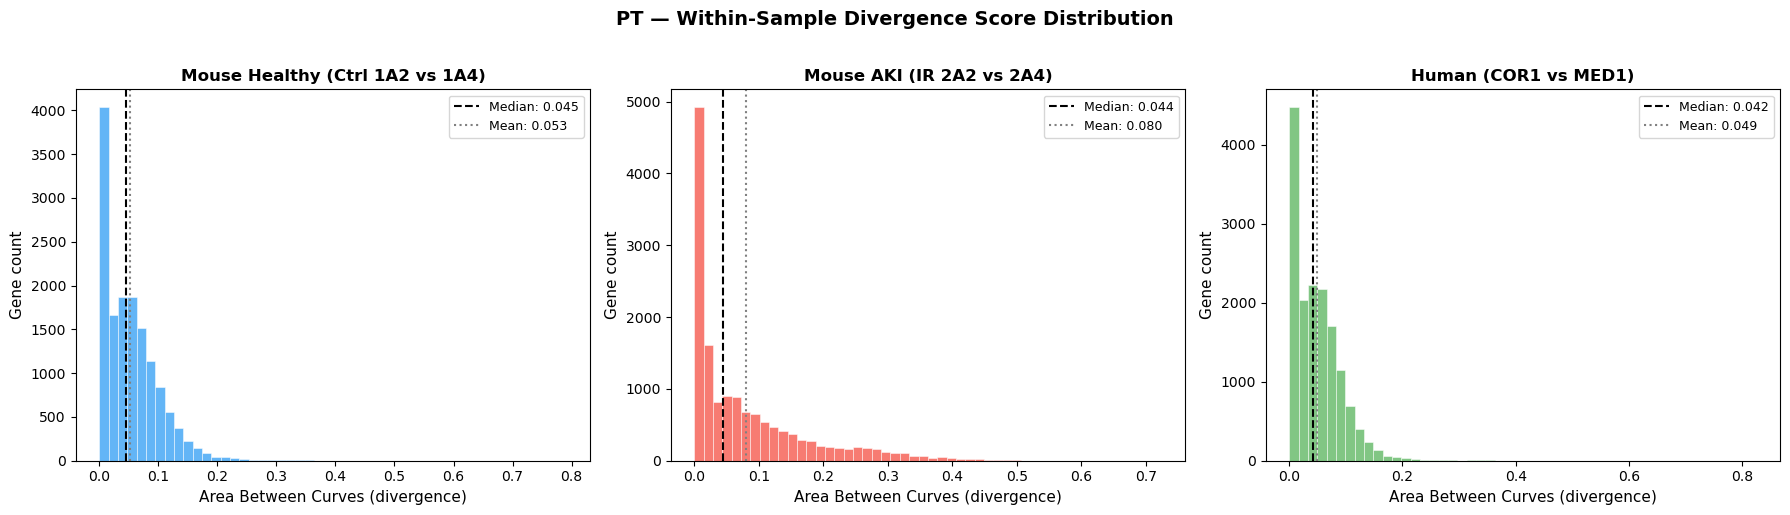

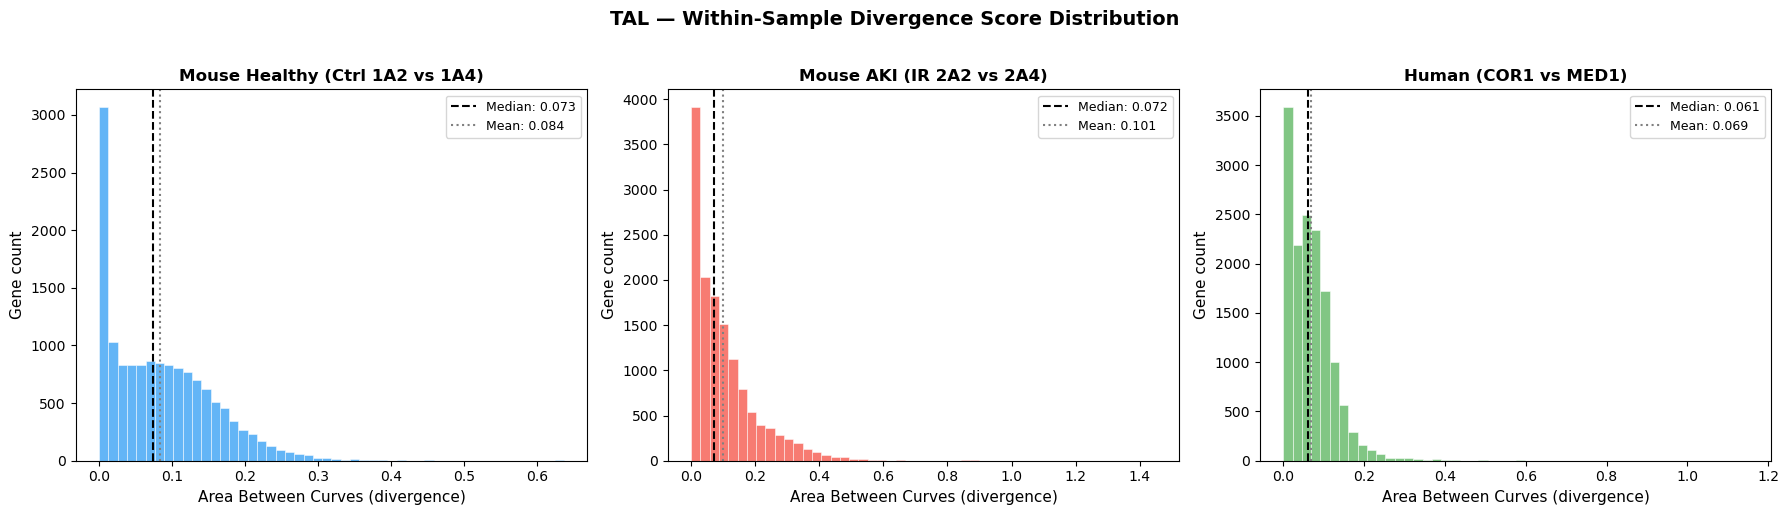

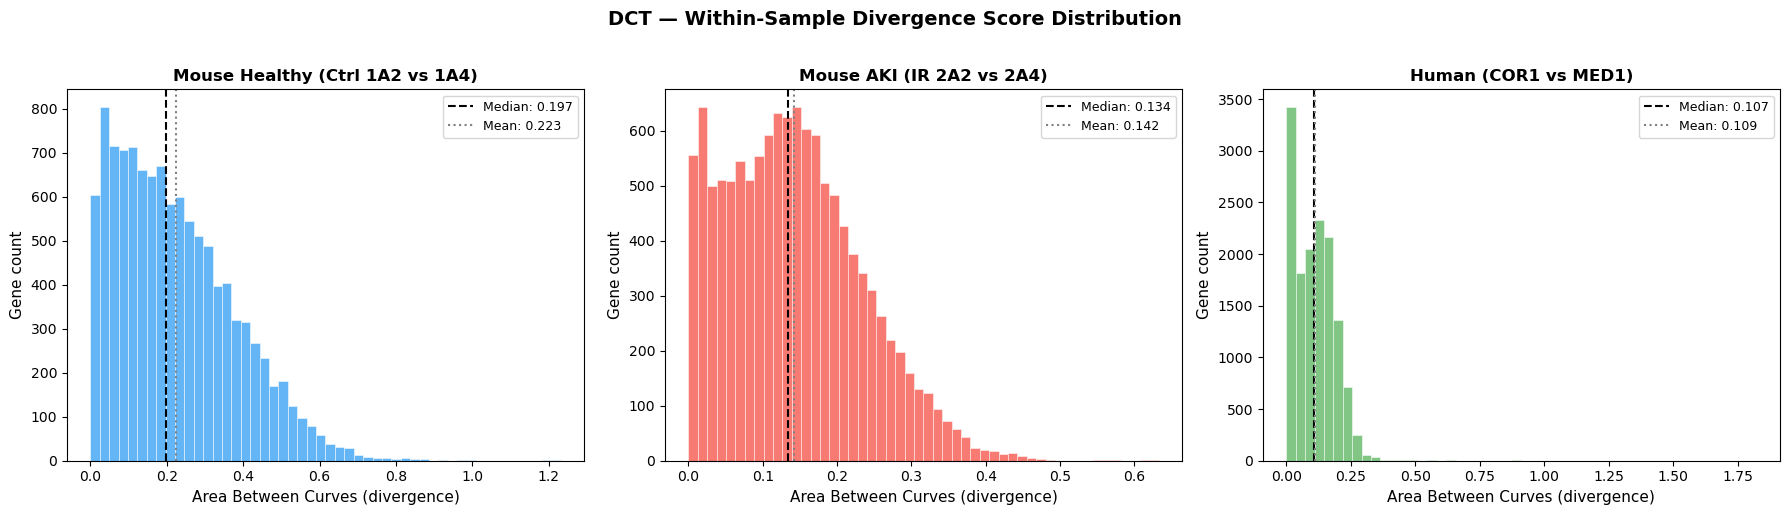

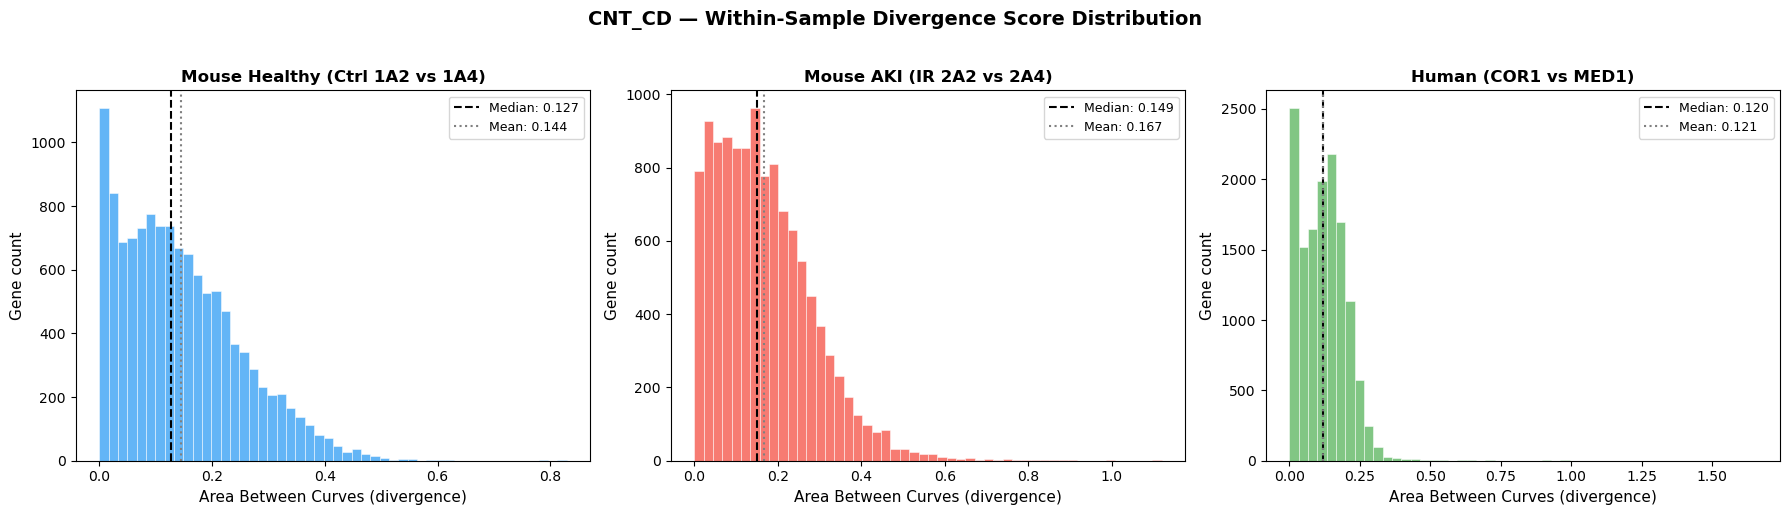

In [6]:
for tt in TUBULE_TYPES:
    if tt not in all_comparison_results or not all_comparison_results[tt]:
        continue
    
    tt_results = all_comparison_results[tt]
    n_comps = len(tt_results)
    
    fig, axes = plt.subplots(1, n_comps, figsize=(6 * n_comps, 5), squeeze=False)
    axes = axes.flatten()
    
    for idx, (comp_name, df) in enumerate(tt_results.items()):
        ax = axes[idx]
        color = COMPARISON_COLORS[comp_name]
        
        ax.hist(df['area_between'], bins=50, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
        ax.axvline(df['area_between'].median(), color='black', linestyle='--', linewidth=1.5,
                   label=f"Median: {df['area_between'].median():.3f}")
        ax.axvline(df['area_between'].mean(), color='gray', linestyle=':', linewidth=1.5,
                   label=f"Mean: {df['area_between'].mean():.3f}")
        
        ax.set_xlabel('Area Between Curves (divergence)', fontsize=11)
        ax.set_ylabel('Gene count', fontsize=11)
        ax.set_title(COMPARISON_LABELS[comp_name], fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
    
    fig.suptitle(f'{tt} — Within-Sample Divergence Score Distribution', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 6. Overlay Divergence Distributions Across Conditions

Compare all three within-sample divergence distributions on a single plot per tubule type to see if any replicate pair is more divergent than others.

/tmp/ipykernel_2477302/3987793685.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_for_box, labels=labels_for_box, patch_artist=True, showfliers=False)


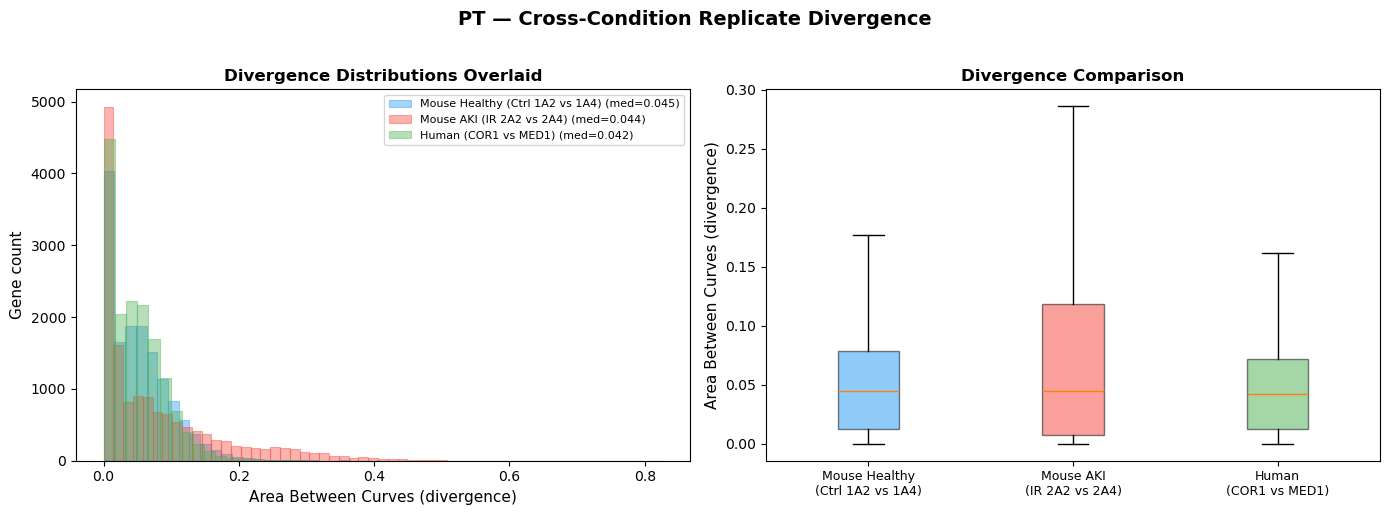

/tmp/ipykernel_2477302/3987793685.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_for_box, labels=labels_for_box, patch_artist=True, showfliers=False)


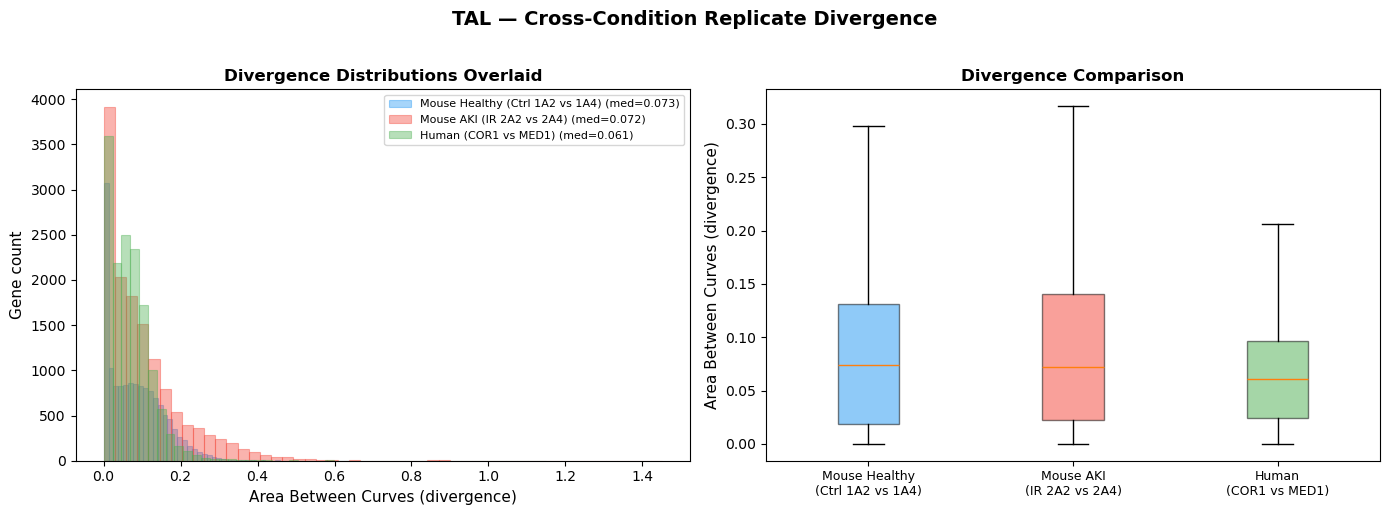

/tmp/ipykernel_2477302/3987793685.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_for_box, labels=labels_for_box, patch_artist=True, showfliers=False)


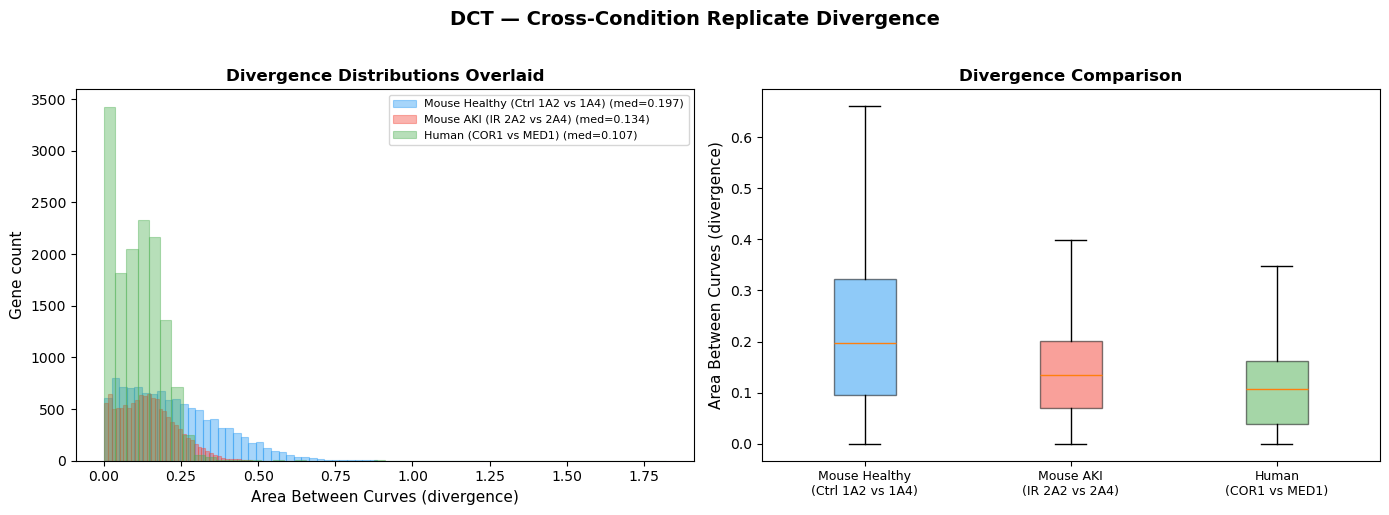

/tmp/ipykernel_2477302/3987793685.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_for_box, labels=labels_for_box, patch_artist=True, showfliers=False)


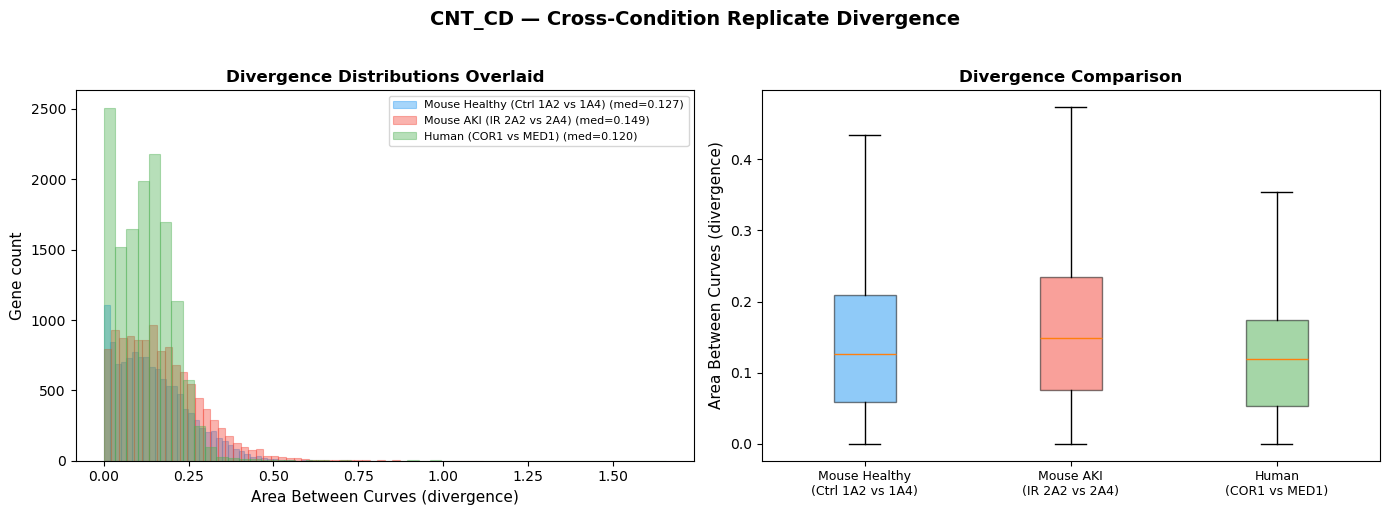

In [7]:
for tt in TUBULE_TYPES:
    if tt not in all_comparison_results or not all_comparison_results[tt]:
        continue
    
    tt_results = all_comparison_results[tt]
    
    if len(tt_results) < 2:
        continue
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: overlaid histograms
    for comp_name, df in tt_results.items():
        color = COMPARISON_COLORS[comp_name]
        label = COMPARISON_LABELS[comp_name]
        ax1.hist(df['area_between'], bins=50, color=color, alpha=0.4, edgecolor=color, linewidth=0.8,
                 label=f"{label} (med={df['area_between'].median():.3f})")
    
    ax1.set_xlabel('Area Between Curves (divergence)', fontsize=11)
    ax1.set_ylabel('Gene count', fontsize=11)
    ax1.set_title('Divergence Distributions Overlaid', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=8)
    
    # Right: box plot comparison
    data_for_box = []
    labels_for_box = []
    colors_for_box = []
    for comp_name, df in tt_results.items():
        data_for_box.append(df['area_between'].values)
        labels_for_box.append(COMPARISON_LABELS[comp_name].replace(' (', '\n('))
        colors_for_box.append(COMPARISON_COLORS[comp_name])
    
    bp = ax2.boxplot(data_for_box, labels=labels_for_box, patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], colors_for_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    
    ax2.set_ylabel('Area Between Curves (divergence)', fontsize=11)
    ax2.set_title('Divergence Comparison', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', labelsize=9)
    
    fig.suptitle(f'{tt} — Cross-Condition Replicate Divergence', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 7. Correlation Score Distributions

Plot the distribution of per-gene correlation scores (high = similar expression patterns).

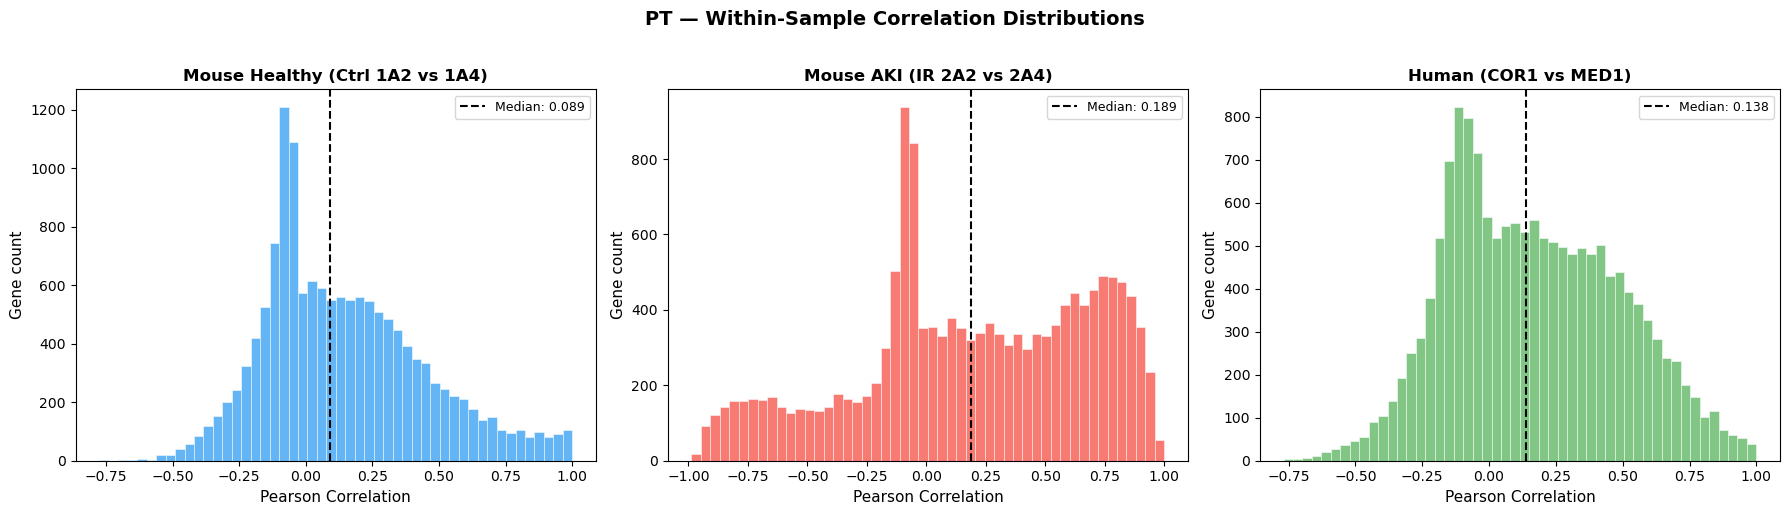

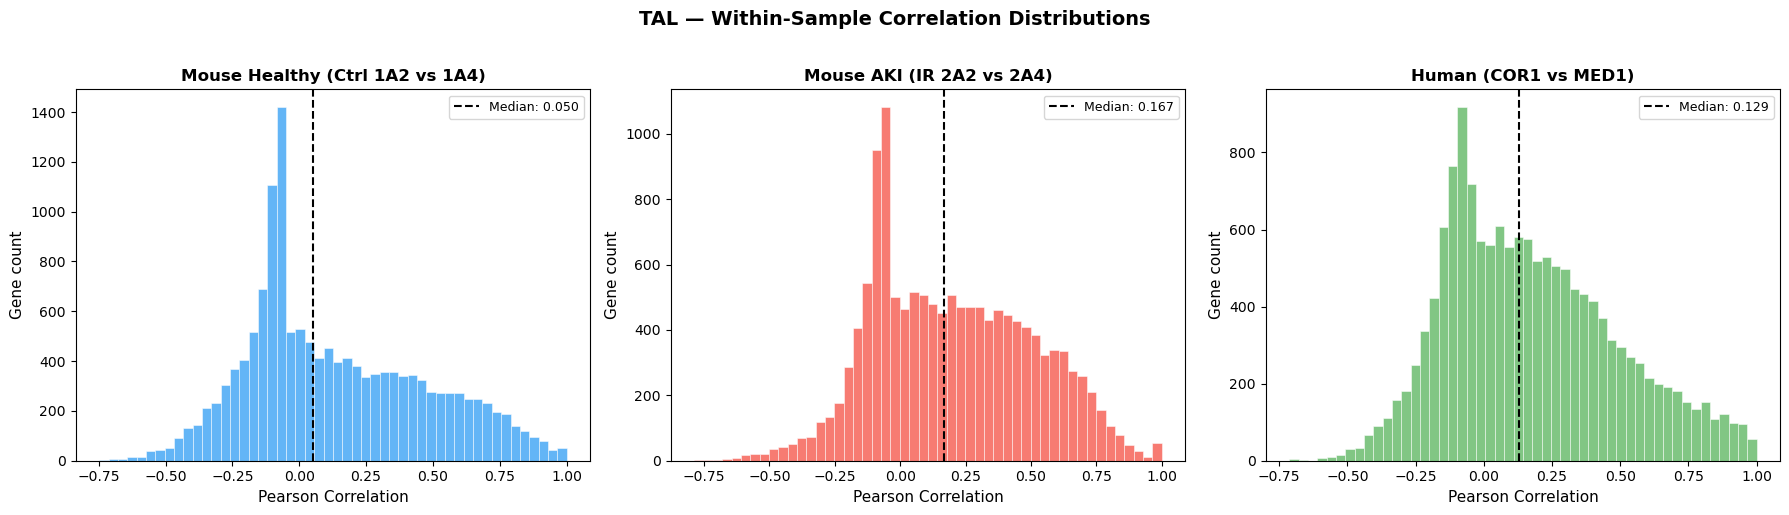

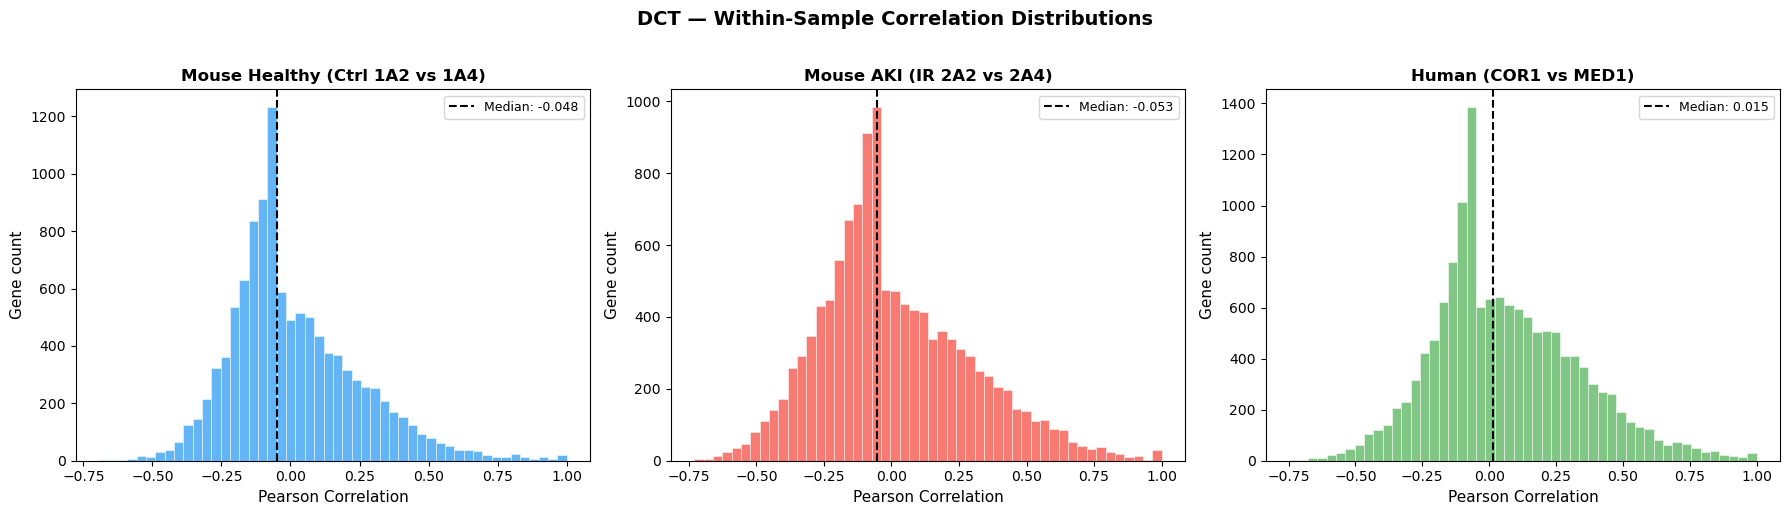

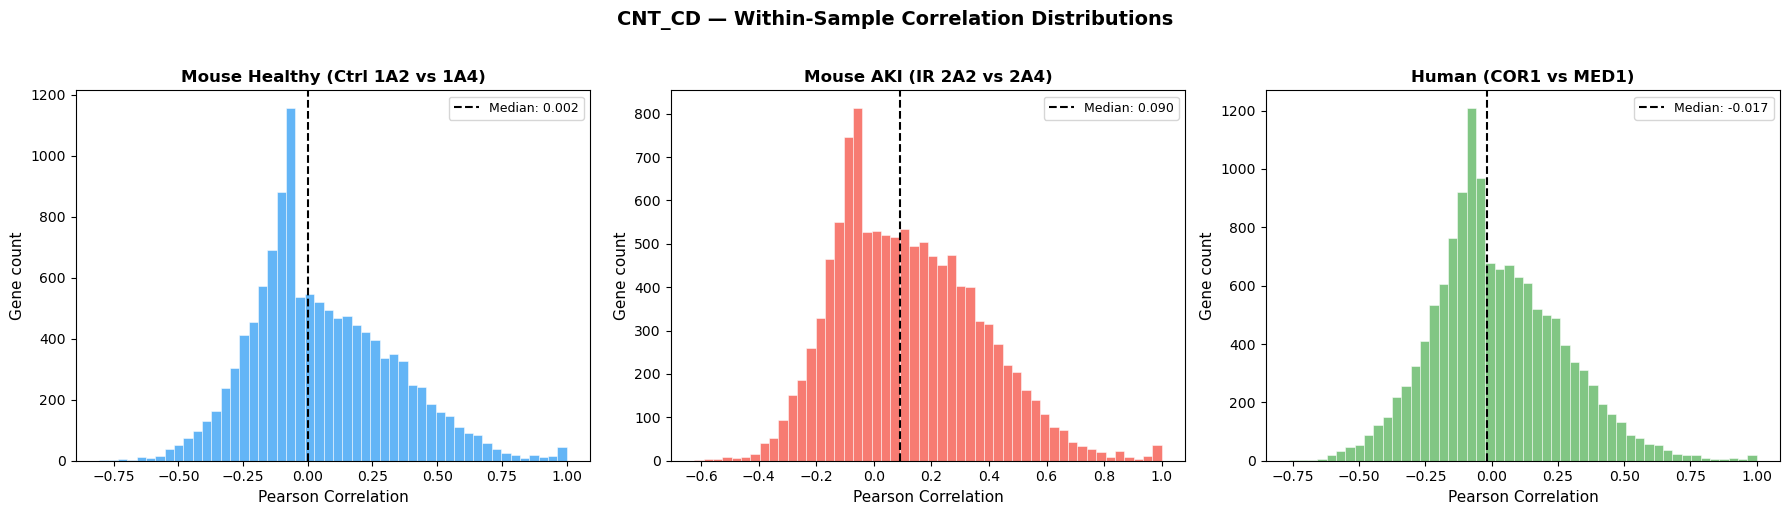

In [8]:
for tt in TUBULE_TYPES:
    if tt not in all_comparison_results or not all_comparison_results[tt]:
        continue
    
    tt_results = all_comparison_results[tt]
    n_comps = len(tt_results)
    
    fig, axes = plt.subplots(1, n_comps, figsize=(6 * n_comps, 5), squeeze=False)
    axes = axes.flatten()
    
    for idx, (comp_name, df) in enumerate(tt_results.items()):
        ax = axes[idx]
        color = COMPARISON_COLORS[comp_name]
        
        valid_corr = df['correlation'].dropna()
        ax.hist(valid_corr, bins=50, color=color, alpha=0.7, edgecolor='white', linewidth=0.5)
        ax.axvline(valid_corr.median(), color='black', linestyle='--', linewidth=1.5,
                   label=f"Median: {valid_corr.median():.3f}")
        
        ax.set_xlabel('Pearson Correlation', fontsize=11)
        ax.set_ylabel('Gene count', fontsize=11)
        ax.set_title(COMPARISON_LABELS[comp_name], fontsize=12, fontweight='bold')
        ax.legend(fontsize=9)
    
    fig.suptitle(f'{tt} — Within-Sample Correlation Distributions', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 8. Top Divergent Genes — Marker Expression Curves

For each tubule type × each comparison, plot the expression curves of the top 5 most divergent genes. These should help identify any systematic batch effects or technical artifacts between replicates.

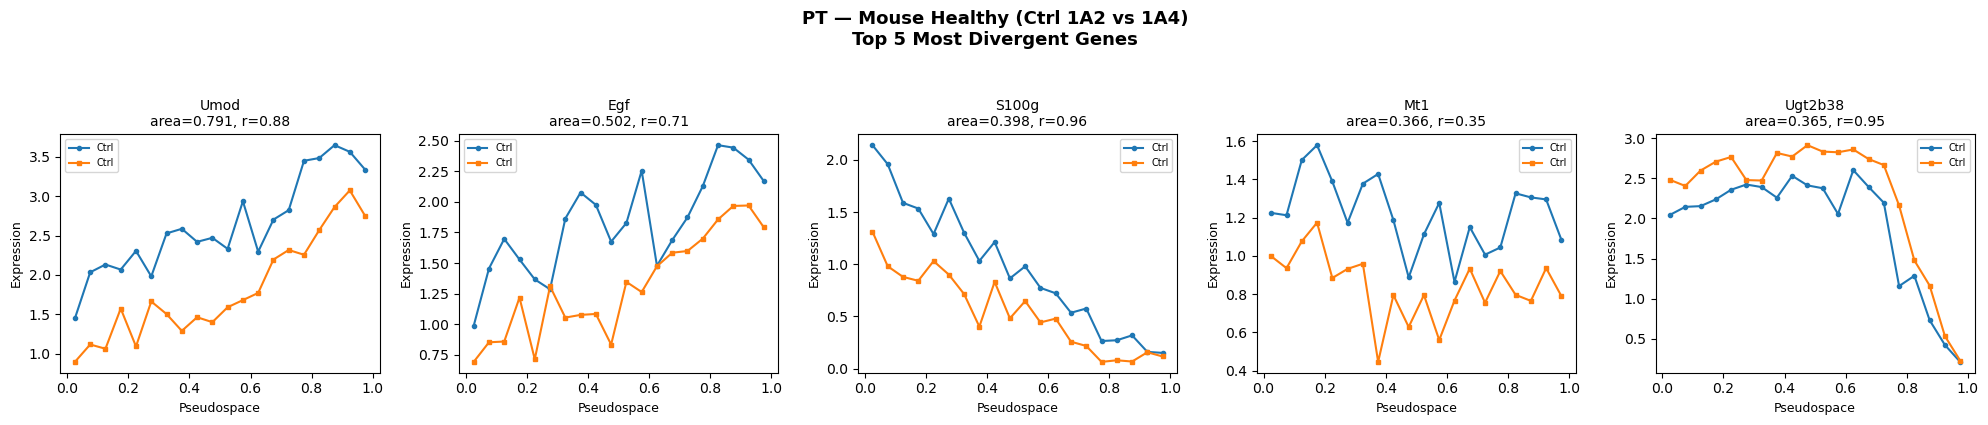

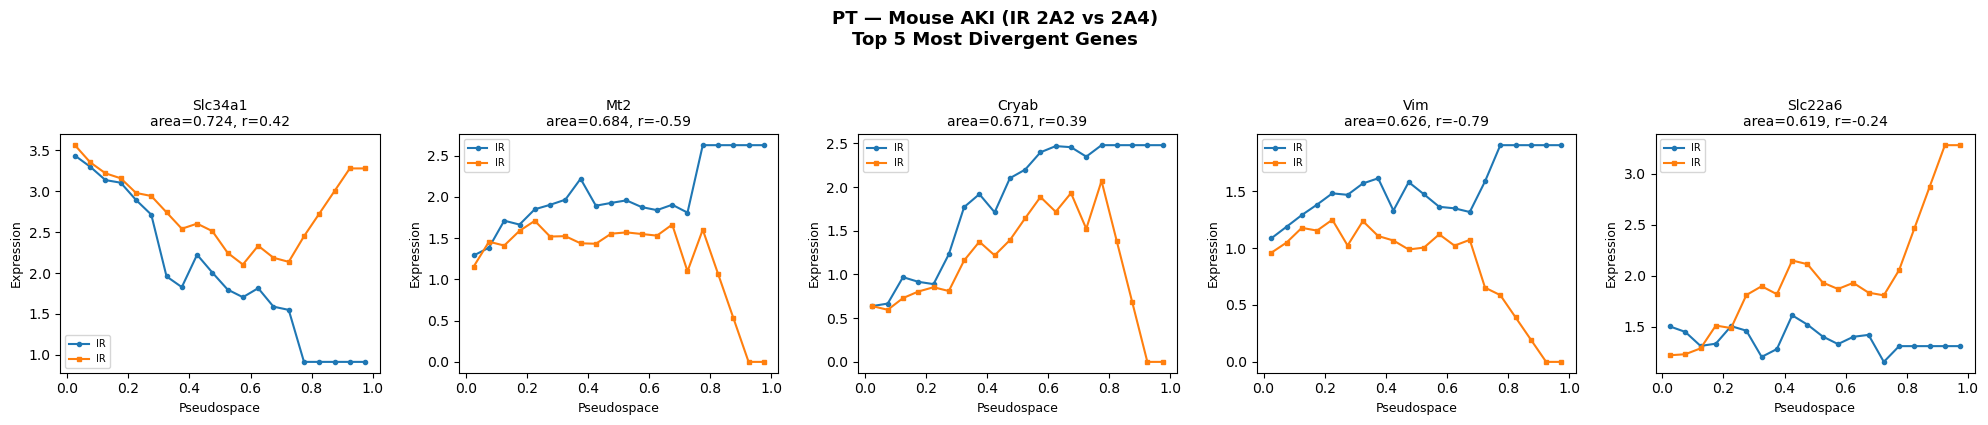

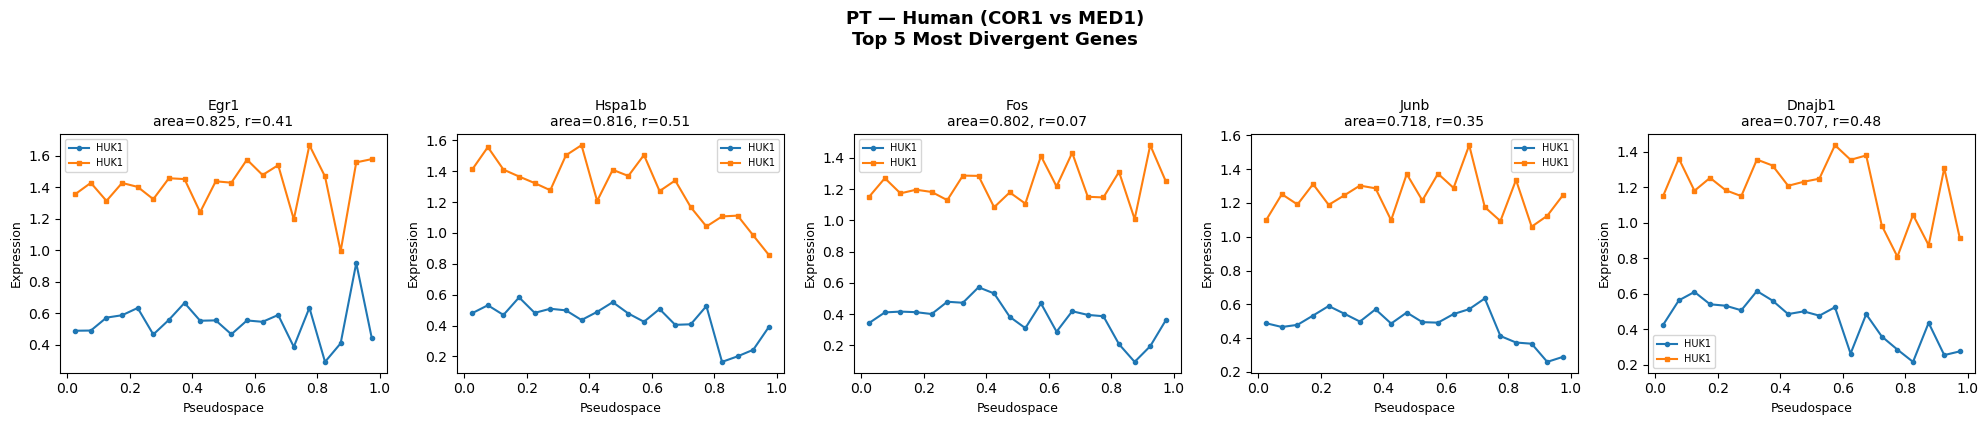

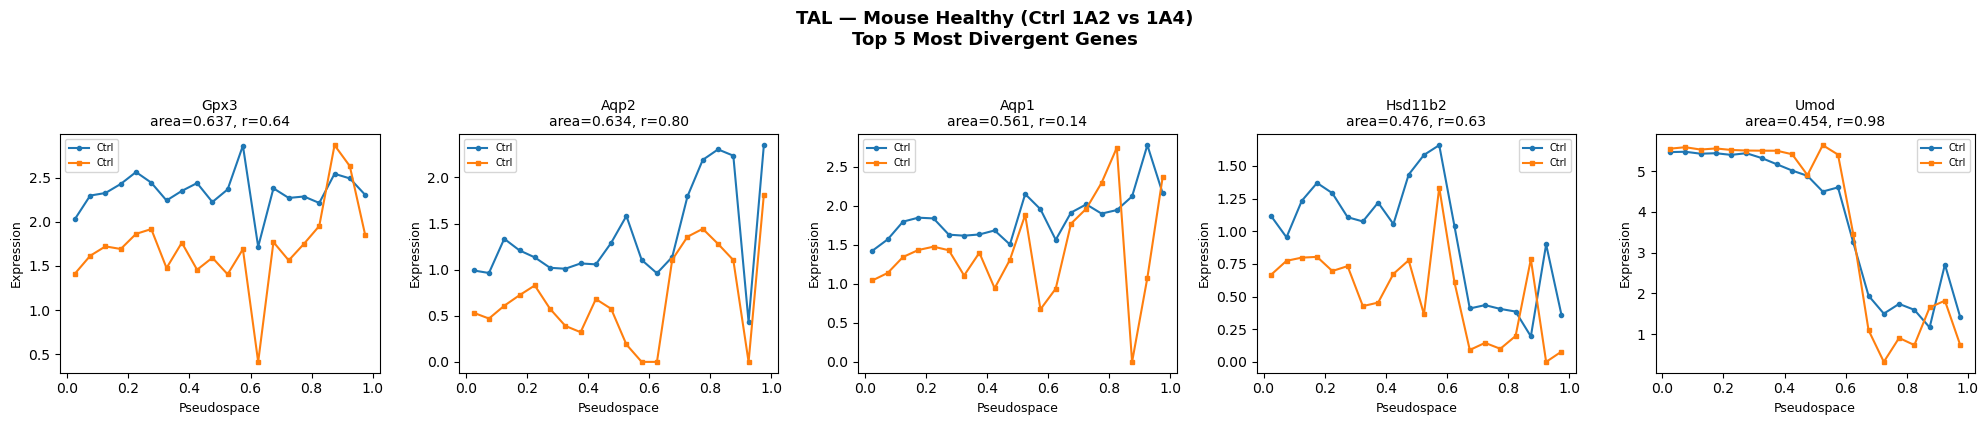

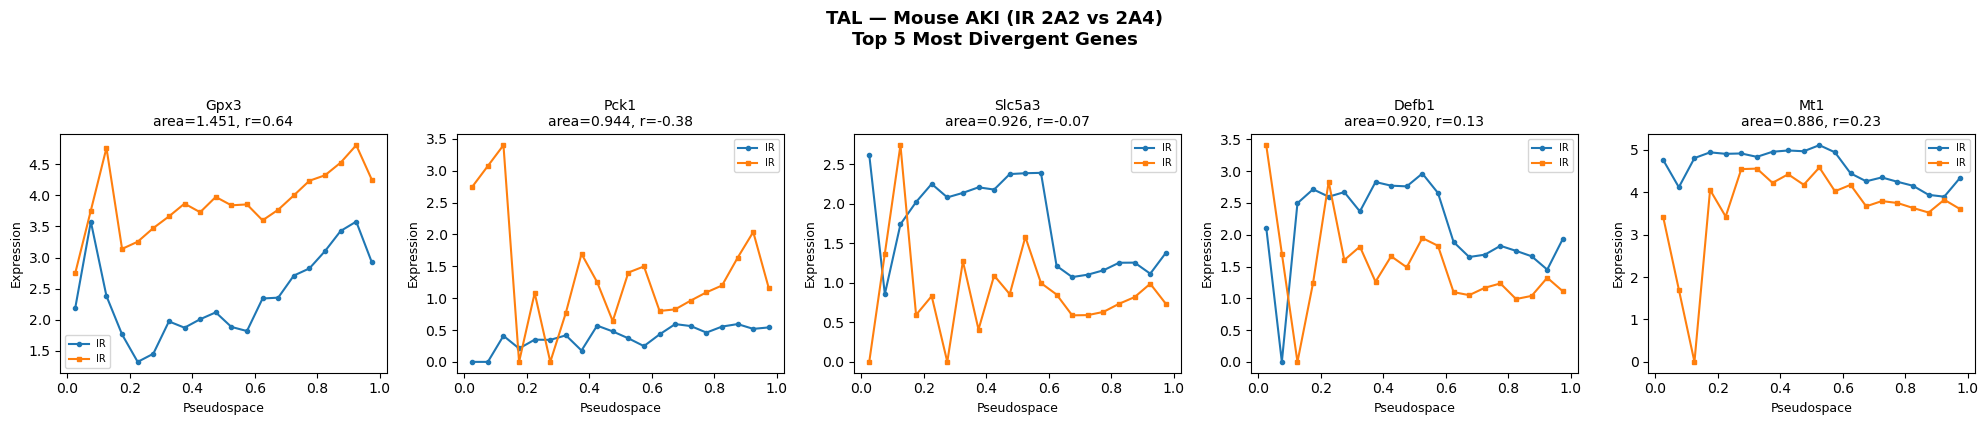

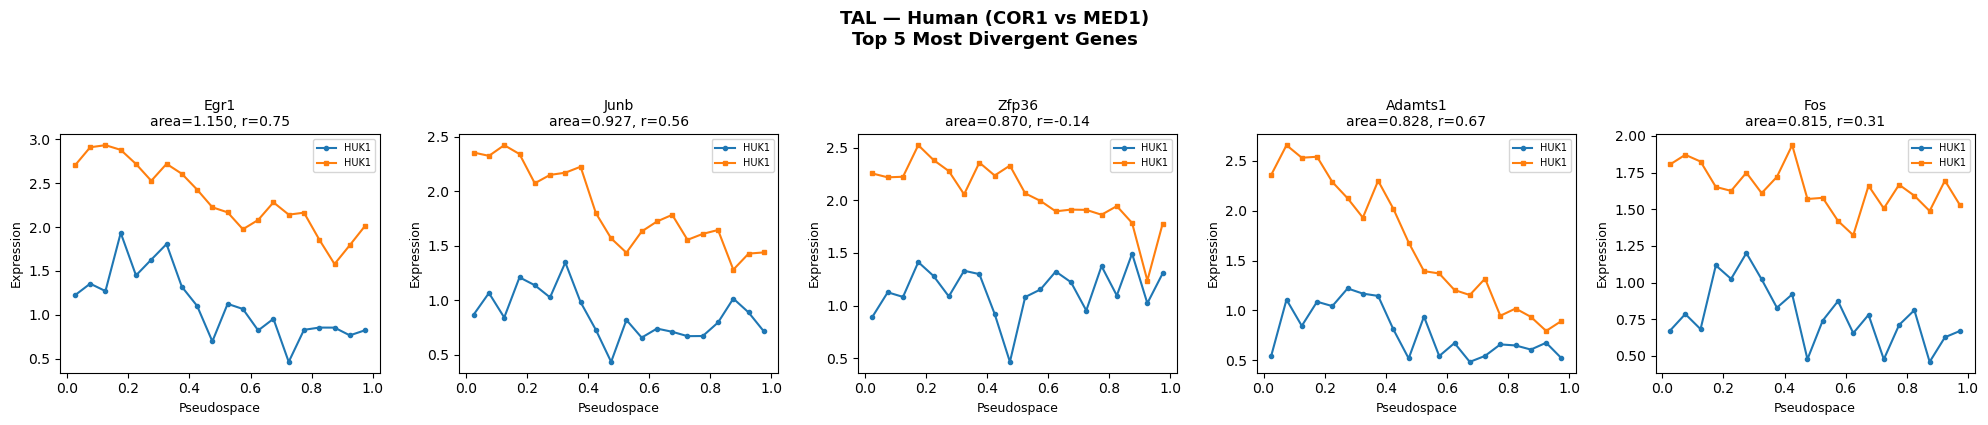

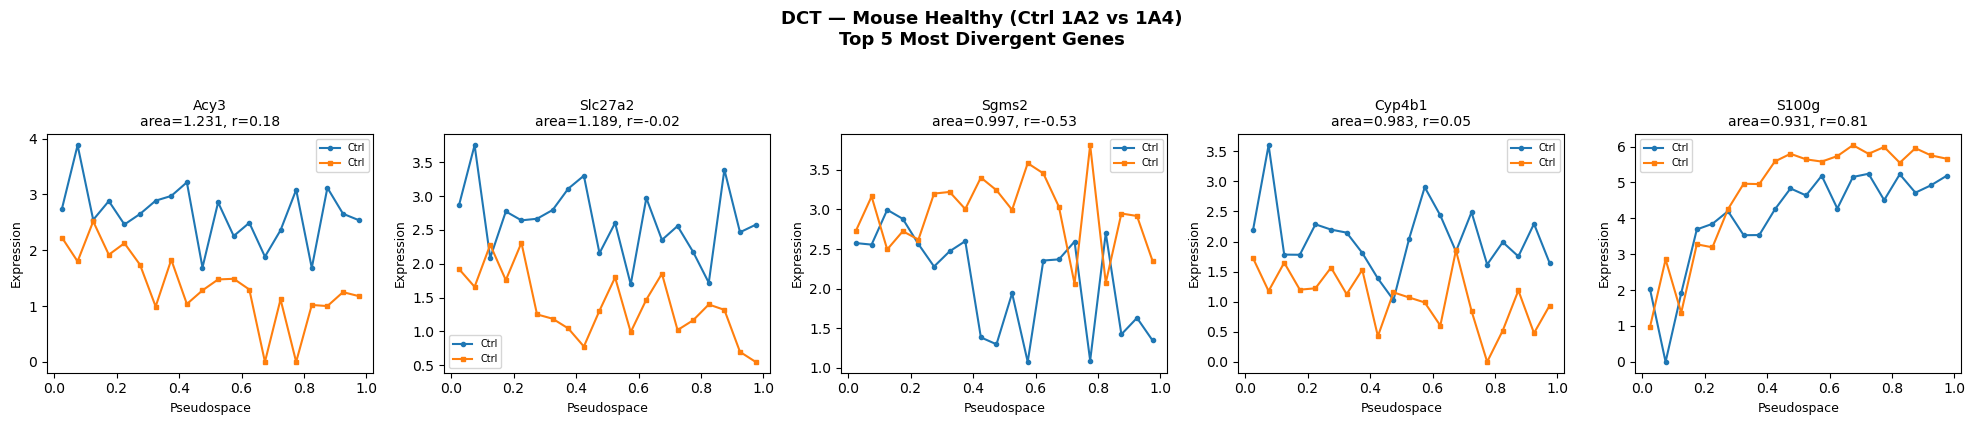

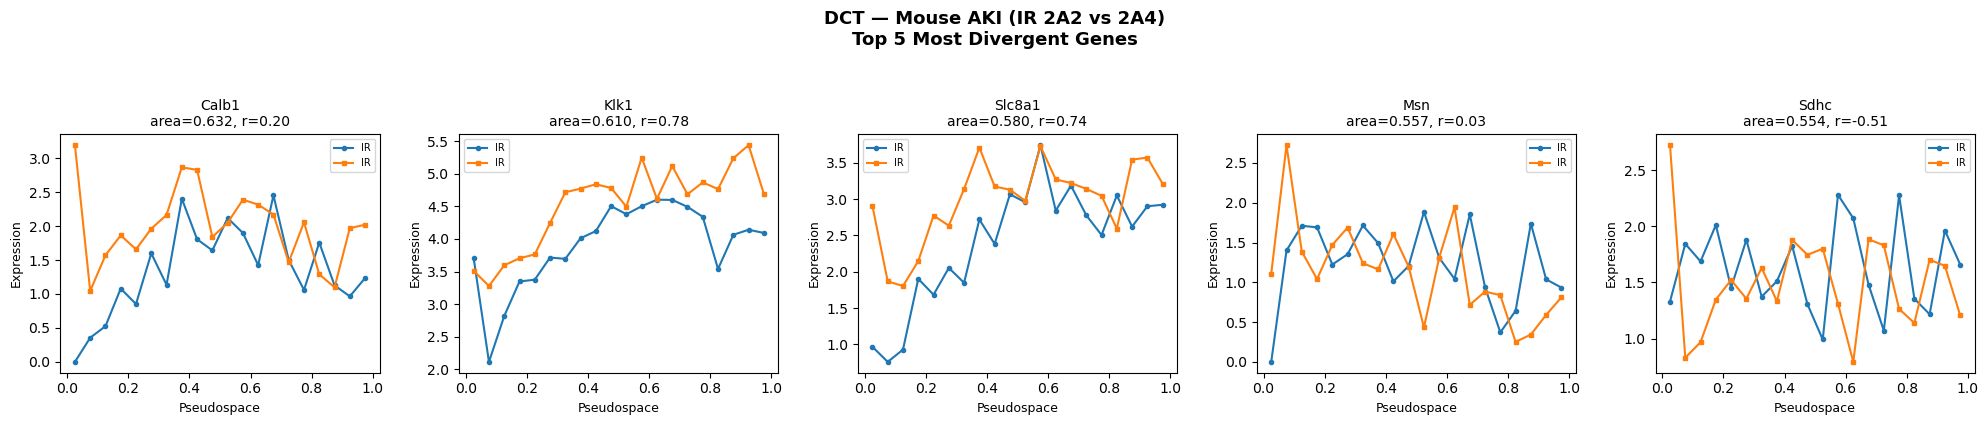

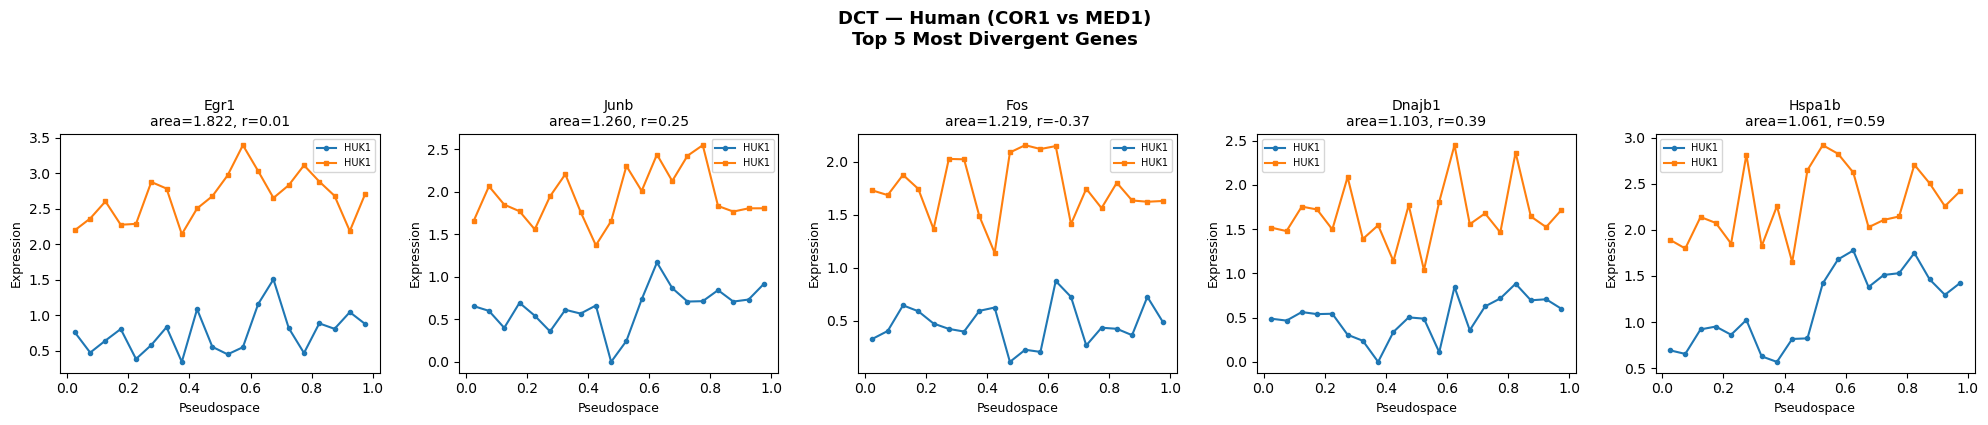

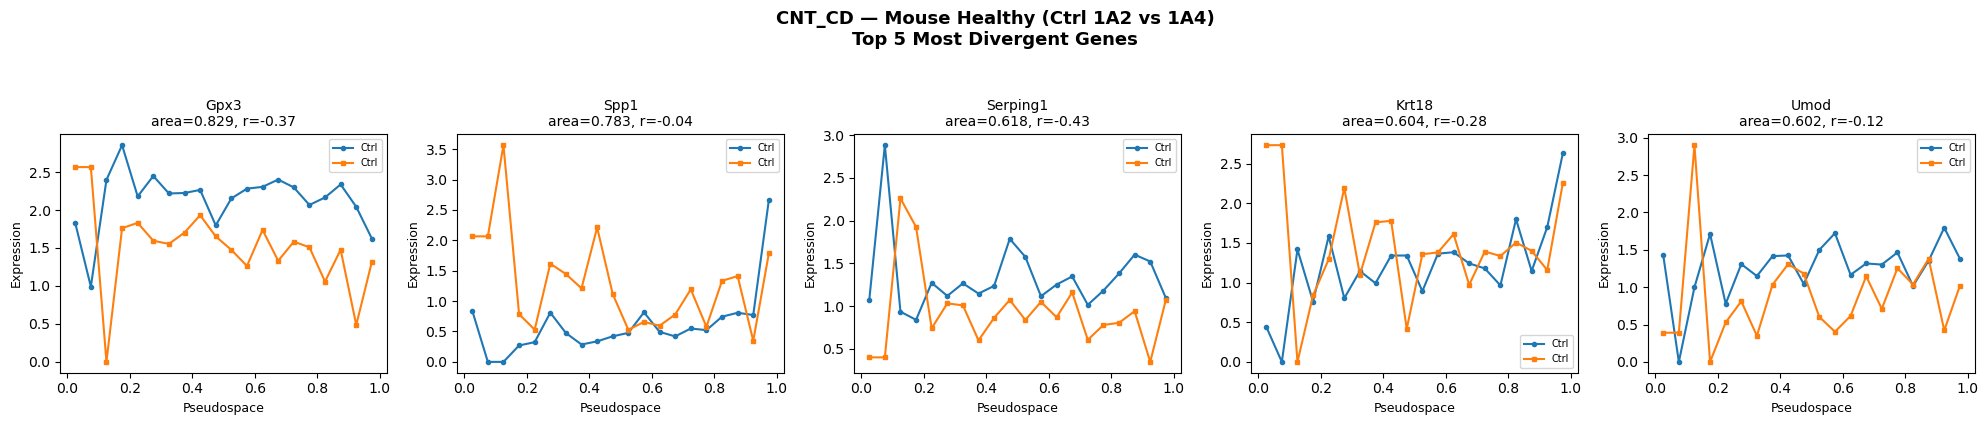

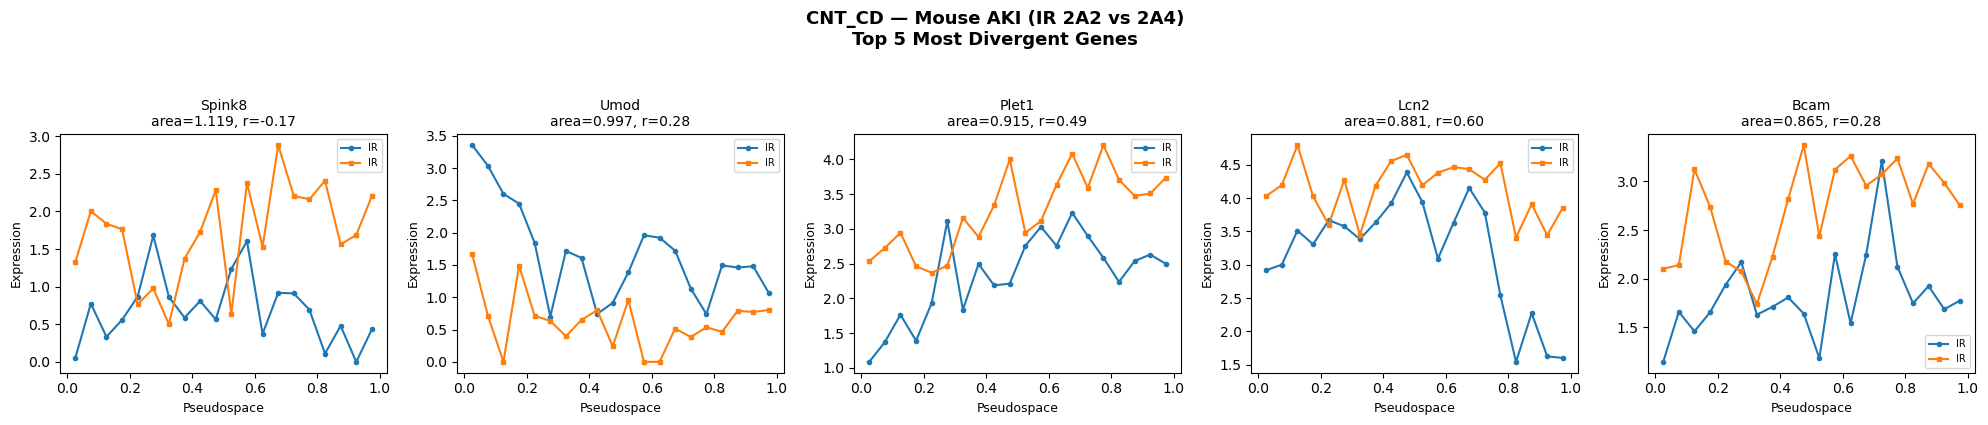

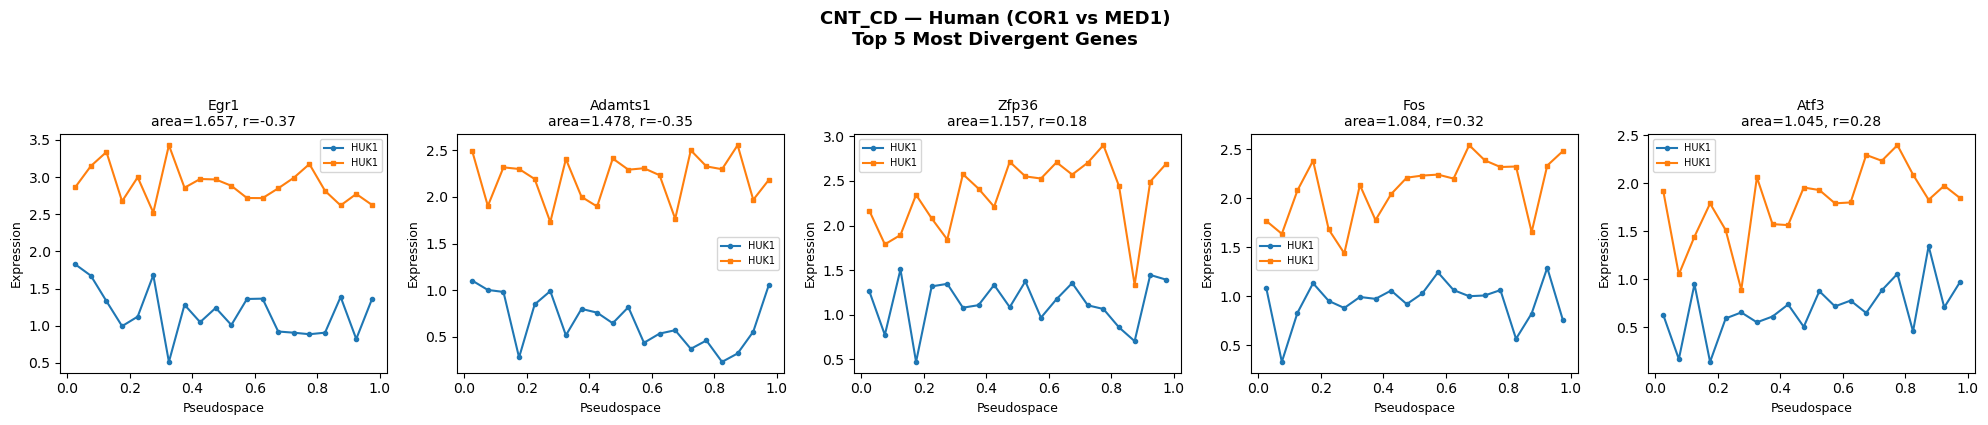

In [9]:
N_TOP = 5
N_BINS = 20

for tt in TUBULE_TYPES:
    if tt not in all_comparison_results or not all_comparison_results[tt]:
        continue
    
    adata = tubule_data[tt]['adata']
    ps_col = tubule_data[tt]['ps_col']
    tt_results = all_comparison_results[tt]
    
    X_dense = adata.X.toarray() if hasattr(adata.X, 'toarray') else np.array(adata.X)
    X_dense = X_dense.astype(np.float64)
    var_names = adata.var_names.tolist()
    
    for comp_name, df in tt_results.items():
        s1, s2 = WITHIN_COMPARISONS[comp_name]
        mask1 = (adata.obs['sample'] == s1).values
        mask2 = (adata.obs['sample'] == s2).values
        
        pos1 = adata.obs.loc[mask1, ps_col].values.astype(np.float64)
        pos2 = adata.obs.loc[mask2, ps_col].values.astype(np.float64)
        idx1 = np.where(mask1)[0]
        idx2 = np.where(mask2)[0]
        
        top_genes = df.head(N_TOP)['gene'].tolist()
        
        fig, axes = plt.subplots(1, N_TOP, figsize=(4 * N_TOP, 4))
        if N_TOP == 1:
            axes = [axes]
        
        bins = np.linspace(0, 1, N_BINS + 1)
        bin_centers = (bins[:-1] + bins[1:]) / 2
        
        for i, gene in enumerate(top_genes):
            gene_idx = var_names.index(gene)
            
            curve1 = get_expression_curve(X_dense[idx1, gene_idx], pos1, N_BINS)
            curve2 = get_expression_curve(X_dense[idx2, gene_idx], pos2, N_BINS)
            
            ax = axes[i]
            if curve1 is not None:
                ax.plot(bin_centers, curve1, 'o-', markersize=3, label=s1.split('_')[0] if '_' in s1 else s1[:8])
            if curve2 is not None:
                ax.plot(bin_centers, curve2, 's-', markersize=3, label=s2.split('_')[0] if '_' in s2 else s2[:8])
            
            area = df.loc[df['gene'] == gene, 'area_between'].values[0]
            corr = df.loc[df['gene'] == gene, 'correlation'].values[0]
            ax.set_title(f"{gene}\narea={area:.3f}, r={corr:.2f}", fontsize=10)
            ax.set_xlabel('Pseudospace', fontsize=9)
            ax.set_ylabel('Expression', fontsize=9)
            ax.legend(fontsize=7)
        
        fig.suptitle(f'{tt} — {COMPARISON_LABELS[comp_name]}\nTop {N_TOP} Most Divergent Genes',
                     fontsize=13, fontweight='bold', y=1.05)
        plt.tight_layout()
        plt.show()

## 9. Summary Table

Aggregate statistics per tubule type × comparison.

In [10]:
summary_rows = []

for tt in TUBULE_TYPES:
    if tt not in all_comparison_results or not all_comparison_results[tt]:
        continue
    
    for comp_name, df in all_comparison_results[tt].items():
        summary_rows.append({
            'Tubule Type': tt,
            'Comparison': COMPARISON_LABELS[comp_name],
            'N Genes': len(df),
            'Median Divergence': round(df['area_between'].median(), 4),
            'Mean Divergence': round(df['area_between'].mean(), 4),
            'Std Divergence': round(df['area_between'].std(), 4),
            'Median Correlation': round(df['correlation'].median(), 4),
            'Pct Correlation > 0.5': f"{(df['correlation'] > 0.5).mean():.1%}",
            '95th Pct Divergence': round(df['area_between'].quantile(0.95), 4),
        })

df_summary = pd.DataFrame(summary_rows)
print("\n" + "="*80)
print(" WITHIN-SAMPLE COMPARISON SUMMARY")
print("="*80)
print()
print(df_summary.to_string(index=False))
print()
print("Low divergence + high correlation = replicates behave consistently along pseudospace.")
print("This establishes the baseline for cross-condition comparisons.")


 WITHIN-SAMPLE COMPARISON SUMMARY

Tubule Type                      Comparison  N Genes  Median Divergence  Mean Divergence  Std Divergence  Median Correlation Pct Correlation > 0.5  95th Pct Divergence
         PT Mouse Healthy (Ctrl 1A2 vs 1A4)    14491             0.0448           0.0525          0.0471              0.0892                 13.3%               0.1376
         PT       Mouse AKI (IR 2A2 vs 2A4)    14792             0.0445           0.0800          0.0957              0.1885                 32.4%               0.2870
         PT            Human (COR1 vs MED1)    15440             0.0420           0.0486          0.0446              0.1377                 17.3%               0.1225
        TAL Mouse Healthy (Ctrl 1A2 vs 1A4)    14508             0.0735           0.0841          0.0712              0.0501                 17.4%               0.2140
        TAL       Mouse AKI (IR 2A2 vs 2A4)    13661             0.0720           0.1008          0.1047              0.1672

## 10. Global Divergence Heatmap

Summary heatmap of median divergence scores across all tubule types and comparisons.

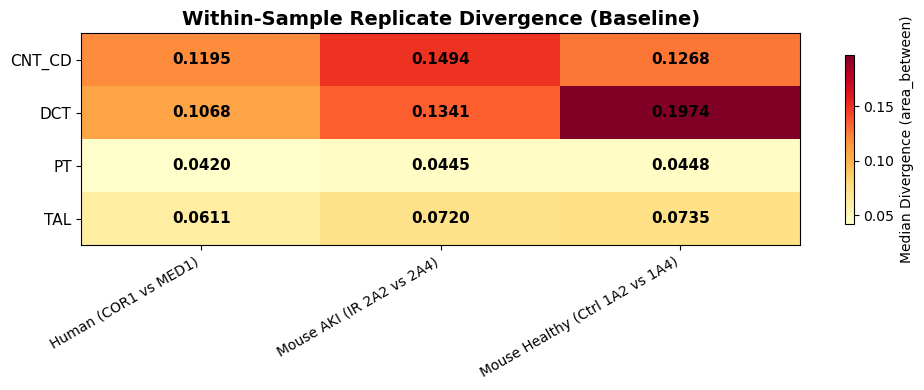

In [11]:
if len(summary_rows) > 0:
    pivot_data = df_summary.pivot(index='Tubule Type', columns='Comparison', values='Median Divergence')
    
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(pivot_data.values, cmap='YlOrRd', aspect='auto')
    
    ax.set_xticks(range(len(pivot_data.columns)))
    ax.set_xticklabels(pivot_data.columns, rotation=30, ha='right', fontsize=10)
    ax.set_yticks(range(len(pivot_data.index)))
    ax.set_yticklabels(pivot_data.index, fontsize=11)
    
    for i in range(len(pivot_data.index)):
        for j in range(len(pivot_data.columns)):
            val = pivot_data.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.4f}", ha='center', va='center', fontsize=11, fontweight='bold')
    
    plt.colorbar(im, ax=ax, label='Median Divergence (area_between)', shrink=0.8)
    ax.set_title('Within-Sample Replicate Divergence (Baseline)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")